# Connecting to the scope

In [ ]:
# This cell is used to show the USB address for the scope. NI-VISA was previously installed
# in the computer for the following to work. It may be found here, https://www.ni.com/en/support/downloads/drivers/download.ni-visa.html

import pyvisa

rm = pyvisa.ResourceManager()
print("Resources:", rm.list_resources())

Following the docs of PyVisa, https://www.pyvisa.com/docs/tektronix-instruments, this is the first cell that they are using

In [ ]:
import pyvisa

rm = pyvisa.ResourceManager()

# USB
scope = rm.open_resource("USB0::0x0699::0x03A6::C047327::INSTR")

scope.timeout = 10000  # 10 s (Tektronix instruments often need longer)
print(scope.query("*IDN?").strip())

scope.write("*RST")
scope.write("*CLS")

# Simple functions which find the scope address and connect to the scope

In [ ]:
from revspace.instrument_drivers.tektronix_scope import obtain_scope_address
serial_number = 'C047327'

scope_address = obtain_scope_address(serial_number)

In [ ]:
from revspace.instrument_drivers.tektronix_scope import connect_to_scope

scope = connect_to_scope(scope_address)

# COMMAND TABLE

## Global commands

In [ ]:
scope.write("ACQuire:STATE ON") # sets the acquisition ON globally (equivalent to pressing "Run")

In [ ]:
scope.write("ACQuire:STATE OFF") # sets the acquisition OFF globally (equivalent to pressing "Stop")

In [ ]:
scope.write("LOCk ALL") # Locks all front-panel controls, useful during measurement!

In [ ]:
scope.write("LOCk NONe") # Unlocks all front-panel controls, useful during measurement!

In [ ]:
scope.write("HORizontal:SCAle 1e-6") # sets the horizontal scale division in units of [s], e.g. 1 us/div

## Channel-specific commands

In [ ]:
scope.write("SELECT:CH1 ON") # turns a channel ON, e.g. Channel 1

In [ ]:
scope.write("SELECT:CH1 OFF") # turns a channel OFF, e.g. Channel 1

In [ ]:
scope.write("CH1:SCAle 0.5") # sets voltage division, in units of [V], e.g. 500 mV/div

In [ ]:
scope.write("CH1:POSition 0.5") # sets the vertical voltage position, in units of [V], e.g. 0.5 V

# Development

In [ ]:
import numpy as np
import pyvisa
import time
from typing import Literal
import matplotlib.pyplot as plt

class Scope:

    def __init__(self,
                 serial_number = 'C047327'):
        
        scope_address = self.obtain_scope_address(serial_number)
        self.com = self.connect_to_scope(scope_address) # self.com is short for self.communications

        self.channels = ['CH1', 'CH2', 'CH3', 'CH4']
        self.ch_scale_min = 5e-3 # in units of [V]
        self.ch_scale_max = 5 # in units of [V]
        self.ch_scale_step = 0.01e-3 # in units of [V]
        self.ch_position_max = 10 # in units of [div]
        self.ch_position_min = -10 # in units of [div]
        self.ch_position_step = 0.04 # in units of [div]
        self.trigger_lvl_min = -8 # in units of [V]
        self.trigger_lvl_max = 8 # in units of [V]
        self.trigger_lvl_step = 40e-3 # in units of [V]

        self.active_config = {'channels': {},
                              'global': {'horizontal scale [s/div]': 1e-6}}
        for channel in self.channels:
            self.active_config['channels'][channel] = {
                'state': 'OFF',
                'scale [V]': 1.0,
                'position [div]': 0.0,
                'coupling': 'DC',
                'bandwidth': 'OFF',
                'probe': 1,
                'invert': 'OFF'}

        # initialization
        print('Initializing instrument ...')
        self.com.write("ACQuire:STATE ON")
        self.com.write("LOCk NONe")
        self.com.write(f"HORizontal:SCAle {self.active_config['global']['horizontal scale [s/div]']}")
        
        for channel in self.channels:
            self.configure_channel(channel=channel,
                                   state=self.active_config['channels'][channel]['state'],
                                   scale=self.active_config['channels'][channel]['scale [V]'],
                                   position=self.active_config['channels'][channel]['position [div]'],
                                   coupling=self.active_config['channels'][channel]['coupling'],
                                   bandwidth=self.active_config['channels'][channel]['bandwidth'],
                                   probe=self.active_config['channels'][channel]['probe'],
                                   invert=self.active_config['channels'][channel]['invert'])
            print(f'Initialized channel {channel} ...')
        self.configure_channel(channel='CH1',
                               state='ON')
        print('Instrument initialized successfully!')


    def obtain_scope_address(self,
                             serial_number):
        """
        Searches all resources and tries to identify an address
        linked to the input serial number.

        Args:
            serial_number (str):
                The input serial number of the device.
                For the Tektronix TDS 2024C it can be found in by pressing
                "Utility > System Status" in the front panel.

        """
        rm = pyvisa.ResourceManager()
        for resource_address in rm.list_resources():
            if serial_number in resource_address:
                print(f"Device with serial number {serial_number} was found with address '{resource_address}'.")
                return resource_address
        raise ValueError(f"Tektronix TDS 2024C with serial number {serial_number} was not found!")
    
    def connect_to_scope(self,
                         scope_address: int):

        rm = pyvisa.ResourceManager()
        scope = rm.open_resource(scope_address)

        scope.timeout = 10000  # 10 s (Tektronix instruments often need longer)
        scope.write("*RST")
        scope.write("*CLS")
        print('Successfully connected:', scope.query("*IDN?").strip())

        return scope
    
    def configure_channel(self,
                          channel: Literal['CH1', 'CH2', 'CH3', 'CH4'],
                          state: Literal['ON', 'OFF'] = None,
                          scale: float = None,
                          position: float = None,
                          coupling: Literal['DC', 'AC', 'GND'] = None,
                          bandwidth: Literal['ON', 'OFF'] = None,
                          probe: Literal[1, 10, 20, 50, 100, 500, 1000] = None,
                          invert: Literal['ON', 'OFF'] = None):
        
        if channel not in ['CH1', 'CH2', 'CH3', 'CH4']:
            raise ValueError(f"Invalid channel input. Valid input options are: ['CH1', 'CH2', 'CH3', 'CH4'].")
        
        if state is not None:
            if state not in ['ON', 'OFF']:
                raise ValueError(f"Invalid state input. Valid input options are: ['ON', 'OFF'].")
            self.com.write(f"SELECT:{channel} {state}")
            self.active_config['channels'][channel]['state'] = state

        # it is important to set the probe prior to setting the scale!
        if probe is not None:
            if probe not in [1, 10, 20, 50, 100, 500, 1000]:
                raise ValueError(f"Invalid probe input. Valid input options are: [1, 10, 20, 50, 100, 500, 1000].") 
            self.com.write(f"{channel}:PRObe {probe}")
            self.active_config['channels'][channel]['probe'] = probe

        if scale is not None:
            scale_valid_inputs = np.round(np.arange(self.ch_scale_min,
                                           self.ch_scale_max+self.ch_scale_step,
                                           self.ch_scale_step), 5)
            if scale not in scale_valid_inputs:
                raise ValueError("Invalid scale input. Valid input options are within "
                                 f"[{self.ch_scale_min} V, {self.ch_scale_max} V] with step size {self.ch_scale_step} V.")
            self.com.write(f"{channel}:SCAle {scale}")
            self.active_config['channels'][channel]['scale [V]'] = scale
            
        if position is not None:
            position_valid_inputs = np.round(np.arange(self.ch_position_min,
                                             self.ch_position_max+self.ch_position_step,
                                             self.ch_position_step), 2)
            if position not in position_valid_inputs:
                raise ValueError("Invalid position input. Valid input options are within "
                                 f"[{self.ch_position_min} div, {self.ch_position_max} div] with step size {self.ch_position_step} div.")
            self.com.write(f"{channel}:POSition {position}")
            self.active_config['channels'][channel]['position [div]'] = position

        if coupling is not None:
            if coupling not in ['DC', 'AC', 'GND']:
                raise ValueError(f"Invalid coupling input. Valid input options are: ['DC', 'AC', 'GND'].")
            self.com.write(f"{channel}:COUPling {coupling}")
            self.active_config['channels'][channel]['coupling'] = coupling

        if bandwidth is not None:
            if bandwidth not in ['ON', 'OFF']:
                raise ValueError(f"Invalid bandwidth input. Valid input options are: ['ON', 'OFF'].")
            self.com.write(f"{channel}:BANdwidth {bandwidth}")
            self.active_config['channels'][channel]['bandwidth'] = bandwidth

        if invert is not None:
            if invert not in ['ON', 'OFF']:
                raise ValueError(f"Invalid invert input. Valid input options are: ['ON', 'OFF'].")
            self.com.write(f"{channel}:INVert {invert}")
            self.active_config['channels'][channel]['invert'] = invert

    def single_measurement(self,
                           channel: Literal['CH1', 'CH2', 'CH3', 'CH4'],
                           trigger_level: float):

        if channel not in ['CH1', 'CH2', 'CH3', 'CH4']:
            raise ValueError("Invalid input channel; valid inputs are: 'CH1', 'CH2', 'CH3', 'CH4'.")
        trigger_lvl_valid_inputs = np.round(np.arange(self.trigger_lvl_min,
                                             self.trigger_lvl_max+self.trigger_lvl_step,
                                             self.trigger_lvl_step), 2)
        if trigger_level not in trigger_lvl_valid_inputs:
            raise ValueError("Invalid trigger level input. Valid input options are within "
                            f"[{self.trigger_lvl_min} V, {self.trigger_lvl_max} V] with step size {self.trigger_lvl_step} V.")

        # Binary encoding for fast transfer
        self.com.write("DAT:ENC RIB")
        self.com.write("DAT:WID 2")      # 16-bit samples
        self.com.write(f"DAT:SOU {channel}")

        # Trigger
        self.com.write("TRIG:MAI:TYP EDGE")
        self.com.write(f"TRIG:MAI:EDGE:SOU {channel}")
        self.com.write(f"TRIG:MAI:LEV {trigger_level}")
        self.com.write("TRIG:MAI:EDGE:SLO RISE")

        # Single acquisition
        self.com.write("ACQ:MODE SAM")
        self.com.write("ACQ:STOPA SEQ")
        self.com.write("ACQ:STATE RUN") # same as pressing "RUN" in front panel

        # Wait for trigger
        start = time.time()
        while time.time() - start < 30:
            if self.com.query("ACQ:STATE?").strip() == "0":
                break
            time.sleep(0.1)

        wfmp = self.com.query("WFMP?").split(";")
        x_scale = float(wfmp[8])
        y_scale = float(wfmp[12])
        y_zero = float(wfmp[13])
        y_offset  = float(wfmp[14])

        raw_voltage_data = np.array(self.com.query_binary_values("CURV?", datatype="h", is_big_endian=True))
        scaled_voltage_data = (raw_voltage_data - y_offset) * y_scale + y_zero
        times = np.arange(len(raw_voltage_data)) * x_scale
        times -= 5 * self.active_config['global']['horizontal scale [s/div]']

        fig, ax = plt.subplots(dpi=100)
        ax.scatter(times,
                   scaled_voltage_data,
                   color = 'C0',
                   alpha = 0.6,
                   label = 'Data',
                   marker = 'o')
        ax.axhline(0.0, color='black', linewidth = 1, linestyle = '--')
        ax.axvline(0.0, color='black', linewidth = 1, linestyle = '--')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Voltage (V)')
        ax.set_ylim(-4.5 * self.active_config['channels']['CH1']['scale [V]'],
                    4.5 * self.active_config['channels']['CH1']['scale [V]'])
        ax.legend()
        ax.grid()

        self.com.write("ACQ:STOPA RUNST") # sets it back to RUN/STOP mode
        self.com.write("ACQ:STATE RUN")

        return {'time [s]': times, 'voltage [V]': scaled_voltage_data}

In [1]:
from revspace.instrument_drivers.tektronix_scope import Scope

scope = Scope()

Device with serial number C047327 was found with address 'USB0::0x0699::0x03A6::C047327::INSTR'.
Successfully connected: TEKTRONIX,TDS 2024C,C047327,CF:91.1CT FV:v24.26
Initializing instrument ...
Initialized channel CH1 ...
Initialized channel CH2 ...
Initialized channel CH3 ...
Initialized channel CH4 ...
Instrument initialized successfully!


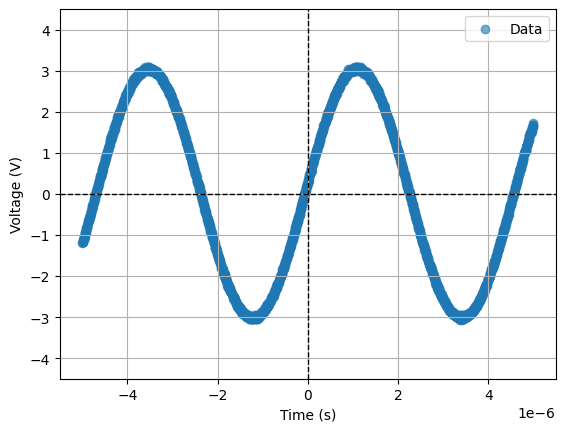

In [3]:
result = scope.single_measurement('CH1',
                                  trigger_level = 0.0)